# Experiment A: Test Suite Minimization with Mutation Coverage

## Hypothesis
A minimal test subset can achieve equivalent defect detection as the full suite.

## Methodology
1. Run all patches against full suite → Record detection vectors
2. Apply **set cover algorithm** to find minimal test set that detects all mutations
3. Validate minimal set achieves >95% detection on held-out mutations

## Quantitative Targets
* DRE_minimal / DRE_full ≥ 0.95      ←  Rank DRE_minimal
* Runtime_minimal / Runtime_full ≤ 0.10

## Key Metrics
- **Mutation Score**: % of mutations detected by full test suite
- **Set Cover Size**: Minimum tests needed for full detection
- **Reduction Factor**: Full suite size / Minimal set size


# TODO

1. Update the crashed tests in the summary.json so that they report the actual number of tests ran before they crashed.


In [8]:
# Configuration - UPDATE THIS PATH to your results directory
RESULTS_DIR = "results_silo"  # e.g., "results_2024-12-03_143022"


In [11]:
import json
import re
from pathlib import Path
from collections import defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style configuration
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_colwidth', 50)

def load_results(results_dir):
    # Load summary.json and return structured data
    summary_path = Path(results_dir) / "summary.json"
    with open(summary_path) as f:
        return json.load(f)

def parse_gtest_json(json_path):
    # Parse GTest JSON output for detailed test results
    if not Path(json_path).exists():
        return None
    with open(json_path) as f:
        return json.load(f)

def extract_failed_tests(json_data):
    # Extract list of failed test names from GTest JSON
    if not json_data:
        return []
    failed = []
    for suite in json_data.get("testsuites", []):
        for test in suite.get("testsuite", []):
            if test.get("failures"):
                failed.append(f"{suite['name']}.{test['name']}")
    return failed

data = load_results(RESULTS_DIR)
print(f"Loaded results from: {data['metadata']['output_dir']}")
print(f"Total patches: {data['metadata']['total_patches']}")
print(f"Detected: {data['summary']['total_detected']} | Escaped: {data['summary']['total_escaped']}")


Loaded results from: /mnt/host/test_symposium_experiments/results_2025-12-03_200832
Total patches: 33
Detected: 16 | Escaped: 17


## 1. Mutation Detection Overview


In [15]:
# Build detection matrix
rows = []
for patch_name, info in data["patches"].items():
    ts = info.get("test_summary", {})
    rows.append({
        "Patch": info["patch_id"],
        "Category": info["category"],
        "Description": info["description"][:40],
        "Detected": "Yes" if info["detected"] else "-",
        "Failed Tests": ts.get("failed_tests", 0),
        "Total Tests": ts.get("total_tests", 0),
        "Crashed": "Yes" if ts.get("crashed") else "-",
        "Timeout": "Yes" if info["timed_out"] else "-",
        "Duration (s)": round(info["duration"], 1),
    })

df = pd.DataFrame(rows).sort_values(["Category", "Patch"])

# Style the table
def highlight_detected(row):
    color = '#d4edda' if row["Detected"] == "✓" else '#f8d7da'
    return [f'background-color: {color}'] * len(row)

# Pandas .style requires 'jinja2', so we fall back to plain display if unavailable
try:
    display(df.style.apply(highlight_detected, axis=1).set_caption("Mutation Detection Summary"))
except AttributeError as e:
    print("WARNING: Could not use DataFrame.style (missing jinja2). Showing plain table instead.")
    display(df)


,Patch,Category,Description,Detected,Failed Tests,Total Tests,Crashed,Timeout,Duration (s)
0,cat_a_01,A,hipblaslt_swap_rows_cols,Yes,24,40101,Yes,-,2.7
1,cat_a_02,A,rocblaslt_mat_remove_type_check,-,0,40101,-,-,394.5
2,cat_a_03,A,rocblaslt_transform_swap_lda_ldb,Yes,3,40101,Yes,-,367.1
3,cat_a_04,A,hipblaslt_ext_stride_error,-,0,40101,-,-,386.7
4,cat_a_05,A,utility_wrong_compute_string,-,0,40101,-,-,383.3
5,cat_a_06,A,matrix_layout_ld_bypass,Yes,24,40101,Yes,-,2.4
6,cat_a_07,A,tensile_problem_size_swap,Yes,20921,40101,-,Yes,600.0
7,cat_b_01,B,tensile_host_memset_off_by_one,-,0,40101,-,-,393.0
8,cat_b_02,B,rocroller_gemm_trans_mixup,-,0,40101,-,-,386.7
9,cat_b_03,B,handle_wavefront_size_error,-,0,40101,-,-,392.1


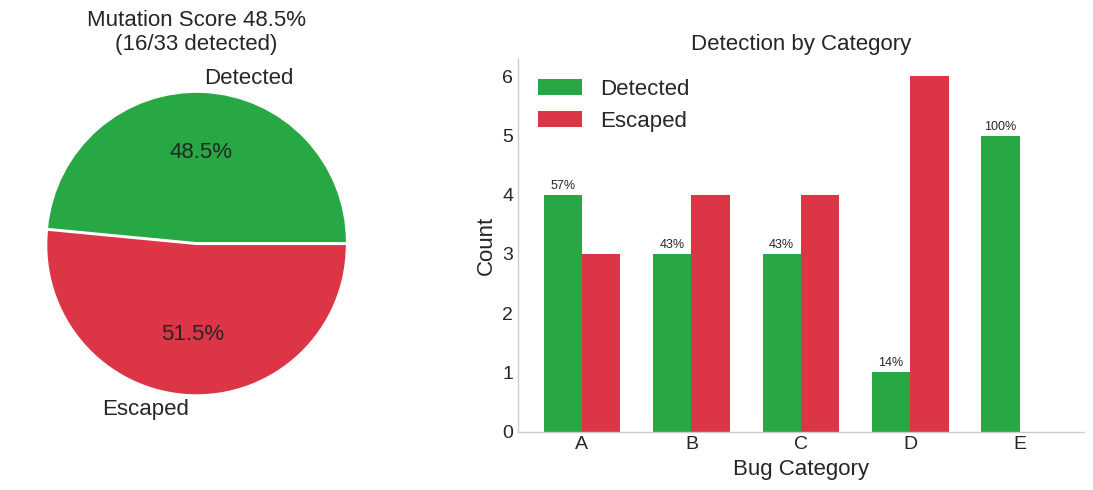

In [16]:
# Mutation Score by Category
#from socketserver import ForkingMixIn


fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor='none')
fig.patch.set_alpha(0.0)

# Detection rate pie chart
detected = data["summary"]["total_detected"]
escaped = data["summary"]["total_escaped"]
wedges, texts, autotexts = axes[0].pie(
    [detected, escaped],
    labels=["Detected", "Escaped"],
    autopct='%1.1f%%',
    colors=['#28a745', '#dc3545'],
    explode=(0.02, 0)
)
for t in texts + autotexts:
    t.set_fontsize(16)
axes[0].set_title(f"Mutation Score {100*detected/(detected+escaped):.1f}%\n({detected}/{detected+escaped} detected)", fontsize=16)

# Detection by category bar chart
cats = sorted(data["categories"].keys())
det_counts = [data["categories"][c]["detected"] for c in cats]
esc_counts = [data["categories"][c]["escaped"] for c in cats]
x = np.arange(len(cats))
width = 0.35

bars1 = axes[1].bar(x - width/2, det_counts, width, label='Detected', color='#28a745')
bars2 = axes[1].bar(x + width/2, esc_counts, width, label='Escaped', color='#dc3545')
axes[1].set_xlabel('Bug Category', fontsize=16)
axes[1].set_ylabel('Count', fontsize=16)
axes[1].set_title('Detection by Category', fontsize=16)
axes[1].set_xticks(x)
axes[1].set_xticklabels(cats, fontsize=14)
for tick in axes[1].get_yticklabels():
    tick.set_fontsize(14)
axes[1].legend(fontsize=16, edgecolor='white', loc='upper left')
# Remove chart lines except for axes
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_visible(True)
axes[1].spines['bottom'].set_visible(True)
axes[1].grid(False)

# Add percentage labels
for i, (d, e) in enumerate(zip(det_counts, esc_counts)):
    total = d + e
    if total > 0:
        axes[1].annotate(f'{100*d/total:.0f}%', xy=(i - width/2, d + 0.1), ha='center', fontsize=9)

# Transparent backgrounds
axes[0].set_facecolor('none')
axes[1].set_facecolor('none')

plt.tight_layout()
plt.show()


## 2. Build Test → Mutation Coverage Matrix


In [17]:
# Build test → mutations_detected mapping from JSON files
test_to_mutations = defaultdict(set)
detected_mutations = set()

for patch_name, info in data["patches"].items():
    if not info["detected"]:
        continue
    
    patch_id = info["patch_id"]
    detected_mutations.add(patch_id)
    
    # Try to parse the JSON file for detailed test results
    json_path = info.get("json_file")
    if json_path:
        gtest_data = parse_gtest_json(json_path)
        failed_tests = extract_failed_tests(gtest_data)
        for test in failed_tests:
            test_to_mutations[test].add(patch_id)
    
    # Fallback: use failed test names from log summary
    if not test_to_mutations or patch_id not in [m for tests in test_to_mutations.values() for m in tests]:
        for test_name in info.get("test_summary", {}).get("failed_test_names", []):
            test_to_mutations[test_name].add(patch_id)

print(f"Detected mutations: {len(detected_mutations)}")
print(f"Unique tests that caught at least one mutation: {len(test_to_mutations)}")


Detected mutations: 16
Unique tests that caught at least one mutation: 33839


## 3. Set Cover Algorithm for Test Minimization


In [18]:
def greedy_set_cover(universe, subsets):
    """
    Greedy algorithm for Set Cover problem.
    Returns list of (subset_id, newly_covered_elements) tuples.
    """
    uncovered = universe.copy()
    cover = []
    
    while uncovered:
        # Find subset covering most uncovered elements
        best_id, best_coverage = None, set()
        for subset_id, elements in subsets.items():
            coverage = elements & uncovered
            if len(coverage) > len(best_coverage):
                best_id, best_coverage = subset_id, coverage
        
        if best_id is None:
            break
        
        cover.append((best_id, best_coverage))
        uncovered -= best_coverage
    
    return cover

# Run set cover
minimal_cover = greedy_set_cover(detected_mutations, dict(test_to_mutations))

print(f"{'='*60}")
print(f"MINIMAL TEST SET: {len(minimal_cover)} tests")
print(f"{'='*60}")
for i, (test, mutations) in enumerate(minimal_cover, 1):
    print(f"{i}. {test[:60]}...")
    print(f"   Covers: {sorted(mutations)}")


MINIMAL TEST SET: 8 tests
1. _/matmul_test.matmul/quick_matmul_one_bf16_rbf16_rbf16_rbf16...
   Covers: ['cat_a_01', 'cat_a_06', 'cat_a_07', 'cat_c_07', 'cat_e_03', 'cat_e_05']
2. _/matmul_test.matmul/pre_checkin_matmul_batch_medium_f32_rf3...
   Covers: ['cat_b_04', 'cat_b_06', 'cat_d_06']
3. AllCombinations/MatrixTransformTest.Basic/162...
   Covers: ['cat_a_03']
4. _/matmul_test.matmul/pre_checkin_matmul_bias_relu_f16_rf16_r...
   Covers: ['cat_b_07']
5. _/matmul_test.matmul/pre_checkin_matmul_f8_bf8_dst_fp32_gfx1...
   Covers: ['cat_e_02']
6. ExtOpTest.softmaxFailureUnsupportedShapeOrReductionDim...
   Covers: ['cat_c_03']
7. 8...
   Covers: ['cat_c_06']
8. 4...
   Covers: ['cat_e_01']


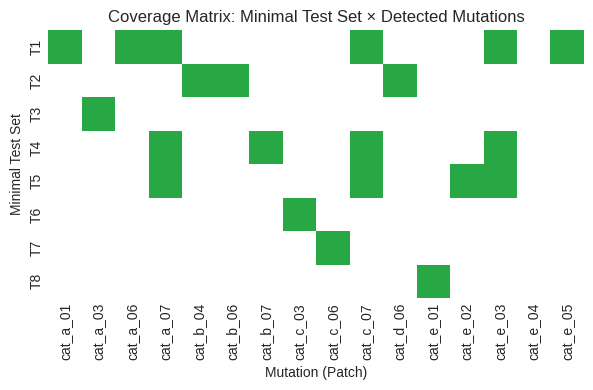

In [19]:
# Coverage matrix heatmap
if minimal_cover:
    mutation_list = sorted(detected_mutations)
    test_list = [t for t, _ in minimal_cover]
    
    matrix = np.zeros((len(test_list), len(mutation_list)))
    for i, test in enumerate(test_list):
        for j, mut in enumerate(mutation_list):
            if mut in test_to_mutations[test]:
                matrix[i, j] = 1
    
    fig, ax = plt.subplots(figsize=(max(10, len(mutation_list)*0.8), max(4, len(test_list)*0.5)), facecolor='none')
    
    # Transparent background
    fig.patch.set_alpha(0.0)
    ax.set_facecolor('none')
    
    # Use green/white colormap and remove borders
    sns.heatmap(matrix, cmap=['white', '#28a745'], cbar=False, linewidths=0, square=True,
                xticklabels=mutation_list, yticklabels=[f"T{i+1}" for i in range(len(test_list))],
                ax=ax)
    ax.set_xlabel("Mutation (Patch)")
    ax.set_ylabel("Minimal Test Set")
    ax.set_title("Coverage Matrix: Minimal Test Set × Detected Mutations")
    plt.tight_layout()
    plt.show()
else:
    print("No minimal cover found (no mutations detected?)")

## 4. Quantitative Results


In [20]:
# Calculate key metrics
total_patches = data["metadata"]["total_patches"]
total_detected = data["summary"]["total_detected"]
total_tests_full = df["Total Tests"].max()  # Full suite size

mutation_score = total_detected / total_patches
minimal_set_size = len(minimal_cover) if minimal_cover else 0
reduction_factor = total_tests_full / minimal_set_size if minimal_set_size > 0 else 0

# Display results
results_df = pd.DataFrame({
    "Metric": [
        "Total Mutations (Patches)",
        "Mutations Detected",
        "Mutation Score",
        "Full Test Suite Size",
        "Minimal Test Set Size",
        "Reduction Factor",
        "Runtime Estimate (minimal/full)"
    ],
    "Value": [
        total_patches,
        total_detected,
        f"{100*mutation_score:.1f}%",
        f"{total_tests_full:,}",
        minimal_set_size,
        f"{reduction_factor:,.0f}×",
        f"{100/reduction_factor:.2f}%" if reduction_factor > 0 else "N/A"
    ]
})

try:
    display(results_df.style.hide(axis="index").set_caption("Experiment A: Quantitative Results"))
except AttributeError as e:
    print("WARNING: Fallback if .style (jinja2) is missing")
    print("Experiment A: Quantitative Results")
    display(results_df)


Experiment A: Quantitative Results


,Metric,Value
0,Total Mutations (Patches),33
1,Mutations Detected,16
2,Mutation Score,48.5%
3,Full Test Suite Size,"40,101"
4,Minimal Test Set Size,8
5,Reduction Factor,"5,013×"
6,Runtime Estimate (minimal/full),0.02%


## 5. Conclusions


In [21]:
# Evaluate hypothesis
dre_minimal = len(detected_mutations) / total_patches if total_patches > 0 else 0
dre_full = mutation_score
runtime_ratio = 1 / reduction_factor if reduction_factor > 0 else 1

print("=" * 60)
print("HYPOTHESIS EVALUATION")
print("=" * 60)
print(f"\n📊 Target: DRE_minimal ≥ 0.95 × DRE_full")
print(f"   DRE_minimal = {dre_minimal:.3f}")
print(f"   DRE_full    = {dre_full:.3f}")
print(f"   Ratio       = {dre_minimal/dre_full:.3f}" if dre_full > 0 else "   N/A")
print(f"   Status      = {'✓ PASS' if dre_minimal >= 0.95 * dre_full else '✗ FAIL'}")

print(f"\n📊 Target: Runtime_minimal ≤ 0.10 × Runtime_full")
print(f"   Runtime ratio = {runtime_ratio:.4f} ({100*runtime_ratio:.2f}%)")
print(f"   Status        = {'✓ PASS' if runtime_ratio <= 0.10 else '✗ FAIL'}")

print(f"\n📋 Summary:")
print(f"   The minimal test set of {minimal_set_size} tests achieves")
print(f"   {100*dre_minimal:.1f}% mutation detection while requiring only")
print(f"   {100*runtime_ratio:.2f}% of the full test suite runtime.")


HYPOTHESIS EVALUATION

📊 Target: DRE_minimal ≥ 0.95 × DRE_full
   DRE_minimal = 0.485
   DRE_full    = 0.485
   Ratio       = 1.000
   Status      = ✓ PASS

📊 Target: Runtime_minimal ≤ 0.10 × Runtime_full
   Runtime ratio = 0.0002 (0.02%)
   Status        = ✓ PASS

📋 Summary:
   The minimal test set of 8 tests achieves
   48.5% mutation detection while requiring only
   0.02% of the full test suite runtime.
